# 6장 실습 — 랜덤화의 폭

4장과 5장은 시뮬을 실기 쪽으로 끌어당기는 길이었다. 이 장부터는 반대 방향이다. **시뮬이 틀려 있다는 것을 전제하고**, 그래도 통하는 정책을 만든다.

방법은 단순하다. 하나의 시뮬이 아니라 파라미터가 매번 달라지는 시뮬의 **분포** 위에서 정책을 최적화한다. 도메인 랜덤화다. 제안된 때부터 지금까지 가장 널리 쓰이는 sim2real 기법이고, 「많이 흔들수록 강건해진다」는 직관 때문에 폭을 겁 없이 키우는 일이 흔하다.

이 노트북은 그 직관이 어디까지 맞는지를 직접 재 본다. 폭을 여섯 단계로 바꿔 가며 같은 최적화를 돌리고, 그때마다 실기 성공률을 잰다. 결과는 단조롭지 않다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 실기와 공칭 모델이 어긋나 있다

과제는 앞 장들과 같은 평면 밀기다. 달라진 것은 두 가지다.

첫째, 성공 반경을 20 mm로 조이고 한 에피소드를 110스텝으로 줄였다. 여유를 없애야 파라미터가 성능을 가른다.

둘째, **우리가 믿는 값이 틀려 있다.** 카탈로그에서 읽었든 대충 넣었든, 손에 든 공칭 모델은 마찰 0.35, 게인 90, 지연 0이다. 실기는 마찰 0.60, 게인 120, 지연 2, 관측 잡음 4 mm다. 이 어긋남이 이 노트북의 출발점이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ, EP_STEPS = 20, 110
GOAL_R, STOP = .02, .012
MU, KV, LAT, NOISE = .60, 120., 2, .004      # 실기
SMU, SKV, SLAT = .35, 90., 0                 # 우리가 믿는 값

CACHE = {}


def get(mu, kv):
    # 모델을 매번 만들면 느리다. 격자로 반올림해 재활용한다
    key = (round(mu, 2), round(kv, 0))
    if key not in CACHE:
        m = mujoco.MjModel.from_xml_string(
            XML.format(mu=key[0], kv=key[1]))
        CACHE[key] = (m, mujoco.MjData(m))
    return CACHE[key]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    return np.array([.34, 0.]) + rng.uniform(-.04, .04, 2)

## 손잡이가 있는 정책

랜덤화가 무언가를 바꾸려면 **바꿀 것이 있어야 한다.** 3장부터 써 온 규칙 정책들은 상수가 박혀 있어 최적화의 대상이 못 된다. 그래서 손잡이 네 개를 뺀다.

- `kp` — 접근할 때의 비례 이득
- `vmax` — 밀 때 내는 속도
- `off` — 블록 뒤 어디에 붙을지 (접근점 거리)
- `tol` — 어느 정도 정렬되면 밀기로 넘어갈지

정책 자체는 여전히 손으로 쓴 규칙이다. 신경망을 쓰지 않는 것은 이 장의 질문이 **표현력**이 아니라 **분포**에 대한 것이기 때문이다. 손잡이 네 개면 폭이 성능을 어떻게 가르는지 보기에 충분하고, 노트북이 CPU에서 돈다.

In [4]:
def mk(th):
    kp, vmax, off, tol = th

    def pol(b, p, g, t):
        dv = unit(g - b)
        if np.linalg.norm(g - b) < STOP:
            return np.zeros(2)
        e = (b - dv * off) - p        # 접근점까지의 오차
        if np.linalg.norm(e) > tol:
            u = kp * e
            n = np.linalg.norm(u)
            return u / n * vmax if n > vmax else u
        return dv * vmax              # 정렬됐으면 민다
    return pol


def ep(pol, rng, mu=MU, kv=KV, lat=LAT, noise=0.):
    m, d = get(mu, kv)
    goal = reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    for t in range(EP_STEPS):
        b = np.asarray(d.qpos[0:2])
        if noise:
            b = b + rng.normal(0, noise, 2)
        buf.append(pol(b, np.asarray(d.qpos[7:9]), goal, t))
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
    return float(np.linalg.norm(d.qpos[0:2] - goal) < GOAL_R)


LO = np.array([2., .05, .03, .003])
HI = np.array([25., .5, .09, .03])
NAMES = ["kp", "vmax", "off", "tol"]

## 폭을 정의한다

폭 w는 공칭값을 중심으로 한 상대 범위다. w = 0.4면 마찰과 게인이 공칭값의 ±40 % 안에서 균등하게 뽑힌다. 지연과 잡음은 0에서 시작해 w에 비례해 커진다.

w = 0은 랜덤화를 끄고 공칭 모델 하나만 쓰는 경우다. 이것이 비교의 출발점이 된다.

여기서 눈여겨볼 것이 하나 있다. 실기의 마찰 0.60은 공칭 0.35의 1.71배다. **w가 0.71을 넘어야 참값이 분포 안에 들어온다.** 게인 쪽은 120 / 90 = 1.33이니 w = 0.33이면 덮인다.

In [5]:
def draw(w, rng):
    # 이 폭에서 시뮬 하나를 뽑는다
    mu = max(SMU * (1 + rng.uniform(-w, w)), .04)
    kv = max(SKV * (1 + rng.uniform(-w, w)), 15.)
    lat = int(rng.integers(0, int(round(w * 5)) + 1))
    noise = float(w * .006 * rng.random())
    return float(mu), float(kv), lat, noise


def sim_score(th, w, seed, n=10):
    # 이 폭의 분포 위에서 정책을 채점한다
    pol = mk(th)
    s = 0.
    for i in range(n):
        r = np.random.default_rng(seed * 1000 + i)
        mu, kv, lat, nz = draw(w, r)
        s += ep(pol, r, mu, kv, lat, nz)
    return s / n


def real_score(th, n=150):
    # 실기에서 채점한다. 최적화는 이 값을 절대 못 본다
    pol = mk(th)
    return float(np.mean([
        ep(pol, np.random.default_rng(7000 + i), MU, KV, LAT, NOISE)
        for i in range(n)]))


for w in (0, .4, 1.0):
    r = np.random.default_rng(0)
    s = [draw(w, r) for _ in range(4)]
    print(f"w = {w}")
    for mu, kv, lat, nz in s:
        print(f"  마찰 {mu:.3f}  게인 {kv:5.1f}  지연 {lat}"
              f"  잡음 {nz*1000:.1f} mm")

w = 0
  마찰 0.350  게인  90.0  지연 0  잡음 0.0 mm
  마찰 0.350  게인  90.0  지연 0  잡음 0.0 mm
  마찰 0.350  게인  90.0  지연 0  잡음 0.0 mm
  마찰 0.350  게인  90.0  지연 0  잡음 0.0 mm
w = 0.4
  마찰 0.388  게인  73.4  지연 0  잡음 0.0 mm
  마찰 0.438  게인 119.7  지연 0  잡음 1.5 mm
  마찰 0.414  게인  93.1  지연 1  잡음 2.0 mm
  마찰 0.211  게인 115.7  지연 2  잡음 0.1 mm
w = 1.0
  마찰 0.446  게인  48.6  지연 1  잡음 0.1 mm
  마찰 0.569  게인 164.3  지연 0  잡음 3.6 mm
  마찰 0.511  게인  97.9  지연 3  잡음 4.9 mm
  마찰 0.040  게인 154.3  지연 5  잡음 0.2 mm


## 최적화기

CEM이다. 4장에서 파라미터를 추정할 때 쓴 것과 같은 알고리즘인데, 이번에는 물리 파라미터가 아니라 **정책 파라미터**를 찾는다.

한 가지를 더 기록한다. 각 세대에서 **엘리트의 점수와 전체 평균의 차이**다. 이 값이 크면 어떤 정책이 좋은지 분포가 알려 주고 있다는 뜻이고, 0에 가까우면 목적함수가 평평해 최적화가 방향을 잃었다는 뜻이다. 나중에 쓸 데가 있다.

In [6]:
def cem(w, iters=4, pop=16, el=4, seed=0):
    mean = (LO + HI) / 2
    std = (HI - LO) / 4
    rs = np.random.default_rng(seed)
    gaps = []
    for it in range(iters):
        P = np.clip(rs.normal(mean, std, (pop, 4)), LO, HI)
        sc = np.array([sim_score(p, w, seed * 97 + it) for p in P])
        idx = np.argsort(-sc)[:el]
        gaps.append(sc[idx].mean() - sc.mean())
        mean = P[idx].mean(0)
        std = P[idx].std(0) + (HI - LO) * .03
    return mean, float(np.mean(gaps))

## 여섯 폭에서 같은 실험을 돌린다

폭마다 CEM을 다섯 번 돌린다. 씨앗 하나로는 CEM 자체의 분산에 결론이 휘둘린다 — 이 실험에서 실제로 겪은 일이고, 논문의 도메인 랜덤화 결과를 읽을 때도 같은 이유로 조심해야 한다.

폭마다 나오는 것은 정책 다섯 개다. 각각을 **자기 훈련 분포**에서, 그리고 **실기**에서 채점한다. 최적화는 실기 점수를 한 번도 보지 않는다.

In [7]:
WIDTHS = [0, .2, .4, .7, 1.0, 1.5]
SEEDS = 5
TH, SIM, REAL, GAP = {}, {}, {}, {}

t0 = time.time()
for w in WIDTHS:
    TH[w], SIM[w], REAL[w], GAP[w] = [], [], [], []
    for sd in range(SEEDS):
        th, g = cem(w, seed=sd)
        TH[w].append(th)
        SIM[w].append(sim_score(th, w, sd * 97 + 99, n=24))
        REAL[w].append(real_score(th))
        GAP[w].append(g)
    print(f"w = {w:<4} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("폭 w", 8) + pad("훈련 분포", 12, True)
      + pad("실기", 10, True) + pad("실기 범위", 16, True))
for w in WIDTHS:
    r = REAL[w]
    print(pad(f"{w:g}", 8) + pad(f"{np.mean(SIM[w]):.3f}", 12, True)
          + pad(f"{np.mean(r):.3f}", 10, True)
          + pad(f"{min(r):.2f} ~ {max(r):.2f}", 16, True))

w = 0    끝  (41s)


w = 0.2  끝  (87s)


w = 0.4  끝  (134s)


w = 0.7  끝  (181s)


w = 1.0  끝  (226s)


w = 1.5  끝  (271s)

폭 w       훈련 분포      실기       실기 범위
0              0.958     0.389     0.20 ~ 0.63
0.2            0.692     0.307     0.04 ~ 0.57
0.4            0.442     0.460     0.12 ~ 0.59
0.7            0.250     0.547     0.42 ~ 0.69
1              0.108     0.323     0.09 ~ 0.55
1.5            0.058     0.267     0.00 ~ 0.66


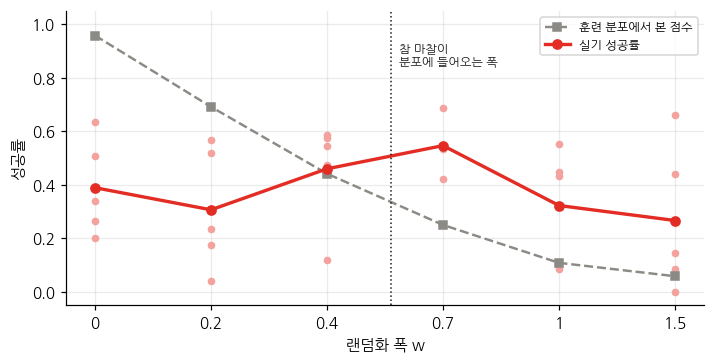

In [8]:
xs = np.arange(len(WIDTHS))
sm = [np.mean(SIM[w]) for w in WIDTHS]
rm = [np.mean(REAL[w]) for w in WIDTHS]

fig, ax = plt.subplots(figsize=(6.6, 3.4))
for i, w in enumerate(WIDTHS):
    ax.plot([i] * SEEDS, REAL[w], "o", color=PINK, ms=4, zorder=2)
ax.plot(xs, sm, "s--", color=GREY, lw=1.6, ms=5,
        label="훈련 분포에서 본 점수")
ax.plot(xs, rm, "o-", color=RED, lw=2.2, ms=6, label="실기 성공률")
ax.axvline(2.55, color=INK, lw=1, ls=":")
ax.text(2.62, .93, "참 마찰이\n분포에 들어오는 폭", fontsize=8,
        color=INK, va="top")
ax.set_xticks(xs)
ax.set_xticklabels([f"{w:g}" for w in WIDTHS])
ax.set_xlabel("랜덤화 폭 w")
ax.set_ylabel("성공률")
ax.set_ylim(-.05, 1.05)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 왜 넓히면 다시 나빠지는가

두 가지를 의심할 수 있다. 정책이 지나치게 보수적으로 변했거나, 최적화가 신호를 잃었거나다. 찾은 파라미터와 앞에서 기록해 둔 엘리트 격차를 같이 본다.

In [9]:
print(pad("폭 w", 8) + pad("엘리트 격차", 14, True)
      + "".join(pad(k, 10, True) for k in NAMES))
for w in WIDTHS:
    th = np.mean(TH[w], 0)
    print(pad(f"{w:g}", 8) + pad(f"{np.mean(GAP[w]):.3f}", 14, True)
          + pad(f"{th[0]:.1f}", 10, True)
          + pad(f"{th[1]:.3f}", 10, True)
          + pad(f"{th[2]:.3f}", 10, True)
          + pad(f"{th[3]:.3f}", 10, True))

폭 w       엘리트 격차        kp      vmax       off       tol
0                0.395      13.9     0.207     0.049     0.016
0.2              0.352      14.5     0.213     0.048     0.013
0.4              0.273      13.9     0.238     0.054     0.017
0.7              0.183      10.3     0.266     0.056     0.017
1                0.129      13.4     0.282     0.054     0.018
1.5              0.085      11.8     0.275     0.049     0.014


## 그럼 무엇으로 채점할 것인가

3장의 질문을 여기에 다시 던진다. 시뮬 점수로 정책들의 순위를 매기면 실기 순위와 맞는가.

여섯 폭에서 나온 정책 서른 개를 세 가지 자로 채점한다.

- **각자의 훈련 분포** — 폭마다 자기가 훈련받은 분포에서 채점한다
- **공통 분포, 공칭 중심** — 모두를 같은 분포에 넣되, 중심은 우리가 믿는 값(마찰 0.35, 게인 90)이다
- **공통 분포, 식별값 중심** — 4장의 방법으로 실기를 식별했다고 치고, 그 값(마찰 0.52, 게인 110, 지연 2) 주변에 좁게 건다. 식별은 완벽하지 않아 참값과 조금 어긋나 있다

In [10]:
def mmrv(pred, real):
    # 3장의 자. 순위가 뒤집힌 쌍을 실기 성능 차이로 무게를 준다
    pred, real = np.asarray(pred), np.asarray(real)
    n = len(pred)
    out = []
    for i in range(n):
        v = [abs(real[i] - real[j])
             for j in range(n)
             if (pred[i] - pred[j]) * (real[i] - real[j]) < 0]
        out.append(max(v) if v else 0.)
    return float(np.mean(out))


def judge(cmu, ckv, clat, cnz, w, n=24):
    # 고정된 자 하나로 여섯 폭의 정책을 모두 채점한다
    out = []
    for wi in WIDTHS:
        s = []
        for k, th in enumerate(TH[wi]):
            pol, acc = mk(th), 0.
            for i in range(n):
                r = np.random.default_rng(900 + k * 100 + i)
                mu = max(cmu * (1 + r.uniform(-w, w)), .04)
                kv = max(ckv * (1 + r.uniform(-w, w)), 15.)
                lat = int(r.integers(max(0, clat - 1), clat + 2))
                acc += ep(pol, r, mu, kv, lat, cnz)
            s.append(acc / n)
        out.append(float(np.mean(s)))
    return out


rea = [np.mean(REAL[w]) for w in WIDTHS]
YARD = {
    "각자의 훈련 분포": [np.mean(SIM[w]) for w in WIDTHS],
    "공통 · 공칭 중심": judge(SMU, SKV, SLAT, 0., .7),
    "공통 · 식별값 중심": judge(.52, 110., 2, NOISE, .2),
}

print(pad("자", 20) + pad("MMRV ↓", 12, True)
      + pad("Pearson r ↑", 14, True))
for k, v in YARD.items():
    r = float(np.corrcoef(v, rea)[0, 1])
    print(pad(k, 20) + pad(f"{mmrv(v, rea):.3f}", 12, True)
          + pad(f"{r:.3f}", 14, True))

자                        MMRV ↓   Pearson r ↑
각자의 훈련 분포           0.134         0.093
공통 · 공칭 중심           0.134         0.173
공통 · 식별값 중심         0.029         0.863


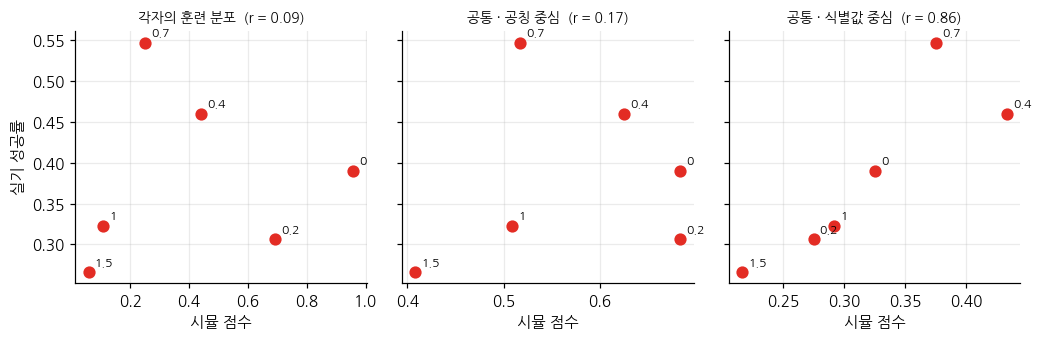

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(9.6, 3.2), sharey=True)
for ax, (k, v) in zip(axs, YARD.items()):
    ax.plot(v, rea, "o", color=RED, ms=7)
    for x, y, w in zip(v, rea, WIDTHS):
        ax.annotate(f"{w:g}", (x, y), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
    r = float(np.corrcoef(v, rea)[0, 1])
    ax.set_title(f"{k}  (r = {r:.2f})", fontsize=9)
    ax.set_xlabel("시뮬 점수")
axs[0].set_ylabel("실기 성공률")
plt.tight_layout()
plt.show()

## 정리

**랜덤화의 폭은 단조롭지 않다.** 실기 성공률은 폭이 커지면서 올라갔다가 다시 내려갔다. 최고점은 참 파라미터가 간신히 분포에 들어오는 자리 근처였다. 「많이 흔들수록 좋다」는 처방은 틀렸다.

**두 힘이 맞선다.** 좁으면 참값을 분포로 덮지 못하고, 넓으면 어떤 정책도 평균적으로 못 풀어서 목적함수가 평평해진다. 뒤쪽 실패는 정책의 보수성이 아니라 **최적화 신호의 소실**로 나타난다. 엘리트 점수와 전체 평균의 격차를 기록하면 그것을 값싸게 감시할 수 있다.

**훈련의 분포와 채점의 분포는 다른 물건이다.** 각자의 훈련 분포로 채점하면 순위가 실기와 어긋난다. 고정된 자로 바꾸는 것만으로도 부족했고, 그 자의 중심을 4장의 식별값 위에 올려 놓고서야 순위가 맞았다. 랜덤화는 훈련의 도구이고 시스템 식별은 평가의 도구다.

**씨앗 하나로 결론을 내지 않는다.** 같은 폭에서도 CEM 씨앗에 따라 실기 성공률이 크게 흩어졌다. 폭을 비교하는 실험은 여러 번 돌려 평균과 산포를 함께 봐야 한다.

다음 장은 남은 질문 하나를 다룬다. 최적의 폭이 있다면, 그것을 **미리 정하지 않고 훈련 중에 키워 가는** 방법이다. 자동 도메인 랜덤화가 그 답을 내놓는 방식과 그 대가를 본다.